# 패키지 불러오기 및 데이터 불러오기

In [37]:
# 사용자 정의 모듈
from hossam import load_data, my_dpi

# 데이터 처리
import numpy as np
from pandas import DataFrame

# 시각화
import seaborn as sb
from matplotlib import pyplot as plt

# 머신러닝
from sklearn.preprocessing import StandardScaler
from sklearn.cluster._dbscan import DBSCAN

# 수학 / 기하
from scipy.spatial import ConvexHull


In [23]:
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [24]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [25]:
origin = load_data("game_usage")
origin.head()

게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


### 데이터 스케일링

In [42]:
scaler = StandardScaler()
df1 = DataFrame(scaler.fit_transform(origin), columns = origin.columns)
df1.head()

,time spent,game level
0,-0.250733,1.474805
1,0.326494,0.606546
2,-0.611500,0.795456
3,0.470801,1.674613
4,-1.405187,-1.558652


### DBSCAN 군집분석

In [43]:
estimator = DBSCAN(eps=0.5, min_samples=5,n_jobs=-1)
estimator.fit(df1)
cluster=estimator.labels_
cluster

array([ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0, -1,  1,  0,
        1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  0,  1,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1, -1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,
        0,  0,  0,  1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0])

### 결과를 포함하는 데이터프레임 생성

In [46]:
df2 = df1.copy()
df2["cluster"] = cluster
df2.head()

,time spent,game level,cluster
0,-0.250733,1.474805,0
1,0.326494,0.606546,0
2,-0.611500,0.795456,0
3,0.470801,1.674613,0
4,-1.405187,-1.558652,1


### 핵심벡터/외곽벡터/노이즈 구분

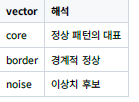

In [49]:
estimator.core_sample_indices_

array([ 1,  2,  4,  5,  7,  8,  9, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 55, 57, 58, 60, 61, 62,
       63, 64, 65, 66, 68, 69, 70, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99])

### 벡터 유형 구분

In [50]:
# 원본 데이터 복사
df3 = df2.copy()

# 기본적으로 모든 포인트를 border로 지정
df3["vector"] = "border"

# 핵심(core) 포인트 지정
df3.loc[
    estimator.core_sample_indices_,
    "vector"
] = "core"

# 노이즈(noise) 포인트 지정
df3.loc[
    df3["cluster"] == -1,
    "vector"
] = "noise"

# 결과 확인
df3.head()


,time spent,game level,cluster,vector
0,-0.250733,1.474805,0,border
1,0.326494,0.606546,0,core
2,-0.611500,0.795456,0,core
3,0.470801,1.674613,0,border
4,-1.405187,-1.558652,1,core


### 결과 시각화

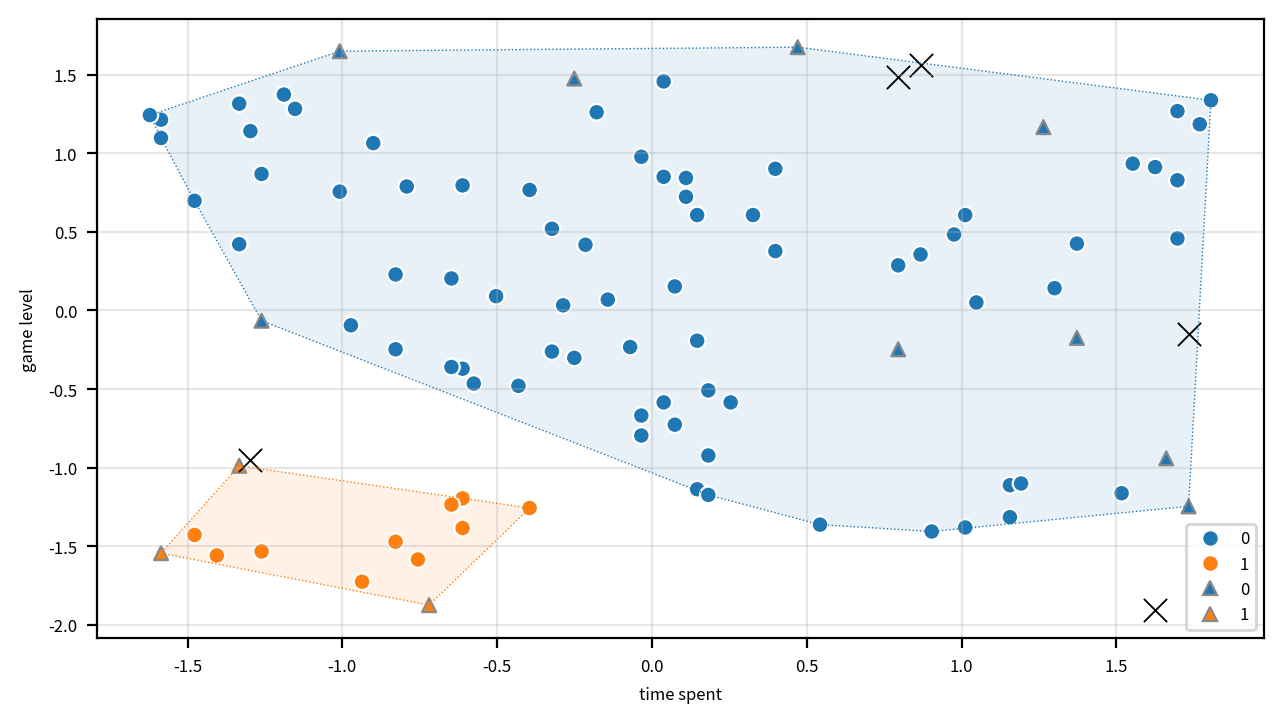

In [51]:
# -------------------------------
# 시각화용 데이터 설정
# -------------------------------
vdf = df3.copy()

hue_field = "cluster"
x_field = "time spent"
y_field = "game level"


# -------------------------------
# 그래프 초기화
# -------------------------------
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 군집별 Convex Hull (noise 제외)
# -------------------------------
for c in vdf[hue_field].unique():

    # 이상치(-1)는 제외
    if c == -1:
        continue

    # 군집별 데이터프레임 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 계산
        hull = ConvexHull(df_c)

        # 마지막 점과 첫 점 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 핵심(core) 포인트
# -------------------------------
sb.scatterplot(
    data=vdf[(vdf[hue_field] != -1) & (vdf["vector"] == "core")],
    x=x_field,
    y=y_field,
    hue=hue_field,
    edgecolor="white",
    linewidth=0.8
)


# -------------------------------
# 경계(border) 포인트
# -------------------------------
sb.scatterplot(
    data=vdf[(vdf[hue_field] != -1) & (vdf["vector"] == "border")],
    x=x_field,
    y=y_field,
    hue=hue_field,
    marker="^",
    s=25,
    edgecolor="#888",
    linewidth=0.8
)


# -------------------------------
# 노이즈(noise) 포인트
# -------------------------------
sb.scatterplot(
    data=vdf[vdf["vector"] == "noise"],
    x=x_field,
    y=y_field,
    color="k",
    marker="x",
    s=70
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


In [ ]:
# -------------------------------
# 모델 객체 생성
# -------------------------------
estimator = DBSCAN(
    eps=0.5,
    min_samples=5,
    n_jobs=-1
)

# -------------------------------
# 모델 학습
# -------------------------------
estimator.fit(df1)

# -------------------------------
# 예측 (DBSCAN은 predict 메서드 없음)
# -------------------------------
cluster = estimator.labels_
cluster


In [ ]:
from sklearn.cluster import DBSCAN
print("DBSCAN OK")


DBSCAN OK


In [ ]:
from sklearn.cluster import DBSCAN
print(DBSCAN)



<class 'sklearn.cluster._dbscan.DBSCAN'>


In [ ]:
from sklearn.cluster import DBSCAN
print(DBSCAN)


<class 'sklearn.cluster._dbscan.DBSCAN'>


![스크린샷 2026-01-23 100423.png](<attachment:스크린샷 2026-01-23 100423.png>)<br>
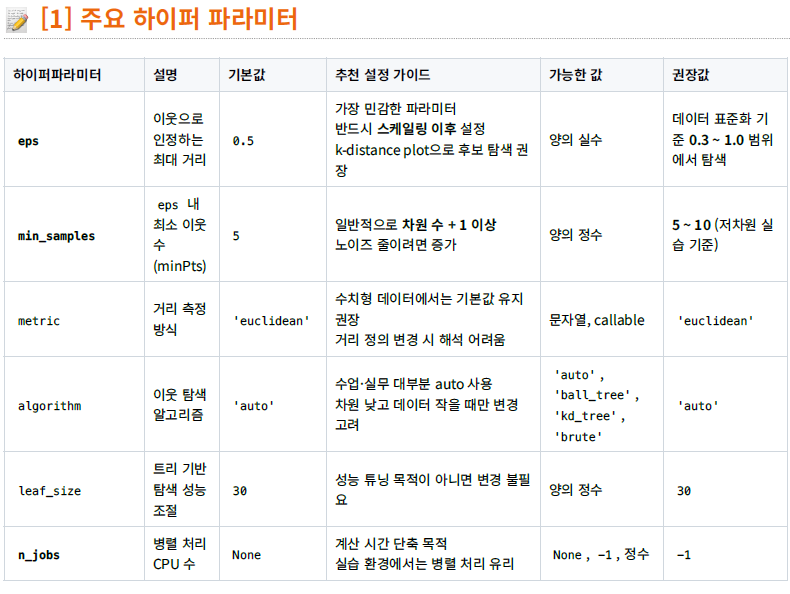<br>
- random_state가 없는 이유
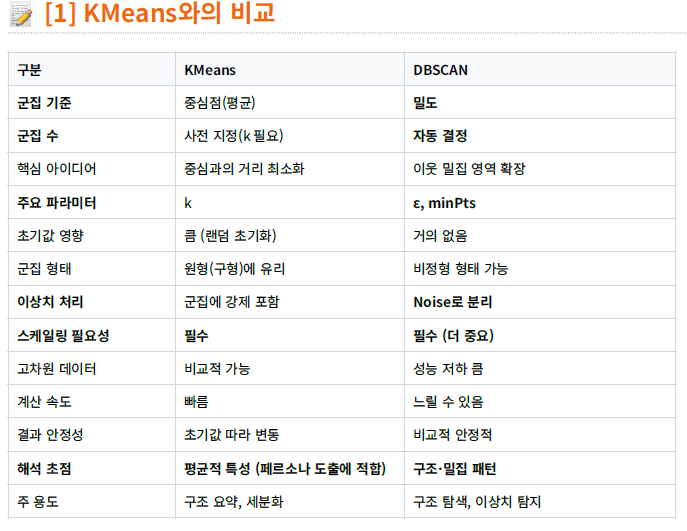